# OpenCLIP LoRA Fine-tuning on CIFAR-10
This notebook fine-tunes OpenCLIP using LoRA (Low-Rank Adaptation) for image classification on CIFAR-10.

**Requirements:**
- Google Colab with GPU (A100, V100, or L4 preferred)
- ~15GB GPU memory available

**Key components:**
- OpenCLIP pre-trained vision transformer
- PEFT LoRA for parameter-efficient fine-tuning
- CIFAR-10 dataset with text prompts
- Training and evaluation pipeline

## 1. Setup & Dependencies

In [1]:
# Check GPU availability
!nvidia-smi

Thu Jun 25 14:29:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   41C    P8             13W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Install required packages
!pip install -q open-clip-torch torch torchvision
!pip install -q peft
!pip install -q transformers
!pip install -q tensorboard
!pip install -q tqdm numpy pandas matplotlib scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 62.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.9 MB/s eta 0:00:00


In [3]:
!pip install -U torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 114.5 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [4]:
# Mount Google Drive for saving results
from google.colab import drive
drive.mount('/content/drive')
print("Google Drive mounted at /content/drive")

Mounted at /content/drive
Google Drive mounted at /content/drive


In [5]:
%cd "/content/drive/MyDrive/research/external_repos"

/content/drive/MyDrive/research/external_repos


In [6]:
# Import libraries
import os
import sys
import json
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, Dataset

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import open_clip
from peft import LoraConfig, get_peft_model, TaskType

# Set random seeds
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Device: cuda
CUDA Available: True
GPU Memory: 23.66 GB


## 2. Configuration

In [7]:
# Configuration
config = {
    # Model config
    'model_name': 'ViT-B-32',  # OpenCLIP model: ViT-B-32, ViT-B-16, ViT-L-14
    'pretrained': 'openai',   # Pre-trained weights: 'openai', 'laion2b_s34b_b79k'

    # LoRA config
    'lora_r': 16,             # LoRA rank
    'lora_alpha': 32,         # LoRA alpha (scaling)
    'lora_dropout': 0.1,      # LoRA dropout
    'lora_target_modules': ['q_proj', 'v_proj'],  # Modules to apply LoRA

    # Training config
    'batch_size': 64,
    'num_epochs': 10,
    'learning_rate': 1e-4,
    'weight_decay': 1e-4,
    'warmup_steps': 100,
    'gradient_accumulation_steps': 2,
    'max_grad_norm': 1.0,

    # Data config
    'image_size': 224,
    'num_workers': 4,

    # Paths
    'save_dir': '/content/gdrive/MyDrive/openclip_lora_cifar10',
    'checkpoint_dir': '/content/gdrive/MyDrive/openclip_lora_cifar10/checkpoints',
}

# Create directories
os.makedirs(config['save_dir'], exist_ok=True)
os.makedirs(config['checkpoint_dir'], exist_ok=True)

# Save config
with open(os.path.join(config['save_dir'], 'config.json'), 'w') as f:
    json.dump(config, f, indent=2)

print("Configuration saved.")
print(json.dumps(config, indent=2))

Configuration saved.
{
  "model_name": "ViT-B-32",
  "pretrained": "openai",
  "lora_r": 16,
  "lora_alpha": 32,
  "lora_dropout": 0.1,
  "lora_target_modules": [
    "q_proj",
    "v_proj"
  ],
  "batch_size": 64,
  "num_epochs": 10,
  "learning_rate": 0.0001,
  "weight_decay": 0.0001,
  "warmup_steps": 100,
  "gradient_accumulation_steps": 2,
  "max_grad_norm": 1.0,
  "image_size": 224,
  "num_workers": 4,
  "save_dir": "/content/gdrive/MyDrive/openclip_lora_cifar10",
  "checkpoint_dir": "/content/gdrive/MyDrive/openclip_lora_cifar10/checkpoints"
}


## 3. Data Loading & Preprocessing

In [8]:
# CIFAR-10 class names
cifar10_classes = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Create text prompts for each class
# Using diverse prompts for better zero-shot/few-shot learning
class_prompts = {
    0: ['a photo of an airplane', 'a picture of a plane', 'an aircraft'],
    1: ['a photo of an automobile', 'a picture of a car', 'a vehicle'],
    2: ['a photo of a bird', 'a picture of a bird', 'an avian'],
    3: ['a photo of a cat', 'a picture of a cat', 'a feline'],
    4: ['a photo of a deer', 'a picture of a deer', 'a cervid'],
    5: ['a photo of a dog', 'a picture of a dog', 'a canine'],
    6: ['a photo of a frog', 'a picture of a frog', 'an amphibian'],
    7: ['a photo of a horse', 'a picture of a horse', 'an equine'],
    8: ['a photo of a ship', 'a picture of a ship', 'a vessel'],
    9: ['a photo of a truck', 'a picture of a truck', 'a lorry'],
}

print(f"Number of classes: {len(cifar10_classes)}")
print(f"Classes: {cifar10_classes}")

Number of classes: 10
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [9]:
# Data transforms
train_transform = transforms.Compose([
    transforms.Resize((config['image_size'], config['image_size'])),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

val_transform = transforms.Compose([
    transforms.Resize((config['image_size'], config['image_size'])),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

print("Data transforms created.")

Data transforms created.


In [10]:
# Load CIFAR-10 dataset
print("Downloading CIFAR-10...")
train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    transform=train_transform,
    download=True
)

val_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    transform=val_transform,
    download=True
)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

Training samples: 50000
Validation samples: 10000


In [11]:
# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=config['batch_size'],
    shuffle=True,
    num_workers=config['num_workers'],
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config['batch_size'],
    shuffle=False,
    num_workers=config['num_workers'],
    pin_memory=True
)

print(f"Training batches per epoch: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Training batches per epoch: 782
Validation batches: 157


## 4. Model Setup with LoRA

In [12]:
# Load OpenCLIP model
print(f"Loading OpenCLIP model: {config['model_name']}...")
model, _, preprocess = open_clip.create_model_and_transforms(
    config['model_name'],
    pretrained=config['pretrained'],
    device=device
)

print(f"Model loaded. Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Loading OpenCLIP model: ViT-B-32...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Model loaded. Total parameters: 151,277,313


In [13]:
# Configure LoRA with correct OpenCLIP module names
lora_config = LoraConfig(
    r=config['lora_r'],
    lora_alpha=config['lora_alpha'],
    lora_dropout=config['lora_dropout'],
    bias='none',
    target_modules=['c_fc', 'c_proj'],  # MLP layers in transformer blocks
)

print("LoRA Config:")
print(lora_config)

LoRA Config:
LoraConfig(task_type=None, peft_type=<PeftType.LORA: 'LORA'>, auto_mapping=None, peft_version='0.19.1', base_model_name_or_path=None, revision=None, inference_mode=False, r=16, target_modules={'c_fc', 'c_proj'}, exclude_modules=None, lora_alpha=32, lora_dropout=0.1, fan_in_fan_out=False, bias='none', use_rslora=False, modules_to_save=None, init_lora_weights=True, layers_to_transform=None, layers_pattern=None, rank_pattern={}, alpha_pattern={}, megatron_config=None, megatron_core='megatron.core', trainable_token_indices=None, loftq_config={}, eva_config=None, corda_config=None, lora_ga_config=None, use_dora=False, alora_invocation_tokens=None, use_qalora=False, qalora_group_size=16, layer_replication=None, runtime_config=LoraRuntimeConfig(ephemeral_gpu_offload=False), lora_bias=False, target_parameters=None, use_bdlora=None, arrow_config=None, ensure_weight_tying=False)


In [14]:
# Apply LoRA to vision transformer
model.visual = get_peft_model(model.visual, lora_config)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Trainable ratio: {trainable_params/total_params*100:.2f}%")

Total parameters: 152,751,873
Trainable parameters: 64,902,657
Trainable ratio: 42.49%


## 5. Training Setup

In [15]:
# Create a classification head for CIFAR-10
class CLIPClassificationHead(nn.Module):
    def __init__(self, vision_model, num_classes=10):
        super().__init__()
        self.vision_model = vision_model
        self.num_classes = num_classes

        # Get embedding dimension from the model
        embed_dim = vision_model.output_dim

        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(512, num_classes)
        )

    def forward(self, images):
        # Get visual features
        with torch.no_grad():
            image_features = self.vision_model(images)

        # Classify
        logits = self.classifier(image_features)
        return logits

# Create classification model
clf_model = CLIPClassificationHead(model.visual, num_classes=len(cifar10_classes)).to(device)

print(f"Classification head created with {len(cifar10_classes)} classes")

Classification head created with 10 classes


In [16]:
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    clf_model.parameters(),
    lr=config['learning_rate'],
    weight_decay=config['weight_decay']
)

# Learning rate scheduler
total_steps = len(train_loader) * config['num_epochs']
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_steps)

print(f"Total training steps: {total_steps}")
print(f"Optimizer: AdamW with lr={config['learning_rate']}")
print(f"Scheduler: Cosine Annealing")

Total training steps: 7820
Optimizer: AdamW with lr=0.0001
Scheduler: Cosine Annealing


## 6. Training Loop

In [18]:
# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'learning_rate': []
}

def train_epoch(model, train_loader, criterion, optimizer, scheduler, device, config):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    pbar = tqdm(train_loader, desc='Training')

    for batch_idx, (images, labels) in enumerate(pbar):
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        logits = model(images)
        loss = criterion(logits, labels)

        # Backward pass
        loss.backward()

        # Gradient accumulation
        if (batch_idx + 1) % config['gradient_accumulation_steps'] == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), config['max_grad_norm'])
            optimizer.step()
            optimizer.zero_grad()
            scheduler.step()

        # Metrics
        total_loss += loss.item()
        preds = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        #pbar.set_postfix({'loss': loss.item():.4f})
        pbar.set_postfix(loss=f'{loss.item():.4f}')

    avg_loss = total_loss / len(train_loader)
    avg_acc = accuracy_score(all_labels, all_preds)

    return avg_loss, avg_acc

def evaluate(model, val_loader, criterion, device):
    """Evaluate on validation set"""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc='Evaluating'):
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            total_loss += loss.item()
            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(val_loader)
    avg_acc = accuracy_score(all_labels, all_preds)

    return avg_loss, avg_acc, all_preds, all_labels

print("Training functions defined.")

Training functions defined.


In [19]:
# Main training loop
best_val_acc = 0
patience = 3
patience_counter = 0

print(f"Starting training for {config['num_epochs']} epochs...\n")

for epoch in range(config['num_epochs']):
    print(f"\n{'='*60}")
    print(f"Epoch {epoch + 1}/{config['num_epochs']}")
    print(f"{'='*60}")

    # Train
    train_loss, train_acc = train_epoch(
        clf_model, train_loader, criterion, optimizer, scheduler, device, config
    )

    # Evaluate
    val_loss, val_acc, _, _ = evaluate(clf_model, val_loader, criterion, device)

    # Log metrics
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['learning_rate'].append(optimizer.param_groups[0]['lr'])

    print(f"\nTrain Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print(f"LR: {optimizer.param_groups[0]['lr']:.6f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        checkpoint_path = os.path.join(config['checkpoint_dir'], f'best_model.pt')
        torch.save({
            'epoch': epoch,
            'model_state_dict': clf_model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'config': config
        }, checkpoint_path)
        print(f"\n✓ Best model saved with val_acc: {val_acc:.4f}")
    else:
        patience_counter += 1
        print(f"\nNo improvement. Patience: {patience_counter}/{patience}")

    # Early stopping
    if patience_counter >= patience:
        print(f"\nEarly stopping triggered. Best val_acc: {best_val_acc:.4f}")
        break

print(f"\n{'='*60}")
print(f"Training completed! Best validation accuracy: {best_val_acc:.4f}")
print(f"{'='*60}")

Starting training for 10 epochs...


Epoch 1/10


Evaluating: 100%|██████████| 157/157 [00:14<00:00, 10.94it/s]



Train Loss: 0.9007 | Train Acc: 0.8171
Val Loss:   0.3452 | Val Acc:   0.9030
LR: 0.000099

✓ Best model saved with val_acc: 0.9030

Epoch 2/10


Evaluating: 100%|██████████| 157/157 [00:14<00:00, 10.73it/s]



Train Loss: 0.3624 | Train Acc: 0.8853
Val Loss:   0.2762 | Val Acc:   0.9139
LR: 0.000098

✓ Best model saved with val_acc: 0.9139

Epoch 3/10


...


Train Loss: 0.2703 | Train Acc: 0.9081
Val Loss:   0.2298 | Val Acc:   0.9237
LR: 0.000065

No improvement. Patience: 1/3

Epoch 9/10


Evaluating: 100%|██████████| 157/157 [00:14<00:00, 10.65it/s]



Train Loss: 0.2712 | Train Acc: 0.9076
Val Loss:   0.2260 | Val Acc:   0.9251
LR: 0.000058

✓ Best model saved with val_acc: 0.9251

Epoch 10/10


Evaluating: 100%|██████████| 157/157 [00:14<00:00, 10.68it/s]


Train Loss: 0.2658 | Train Acc: 0.9091
Val Loss:   0.2259 | Val Acc:   0.9249
LR: 0.000050

No improvement. Patience: 1/3

Training completed! Best validation accuracy: 0.9251


## 7. Results & Visualization

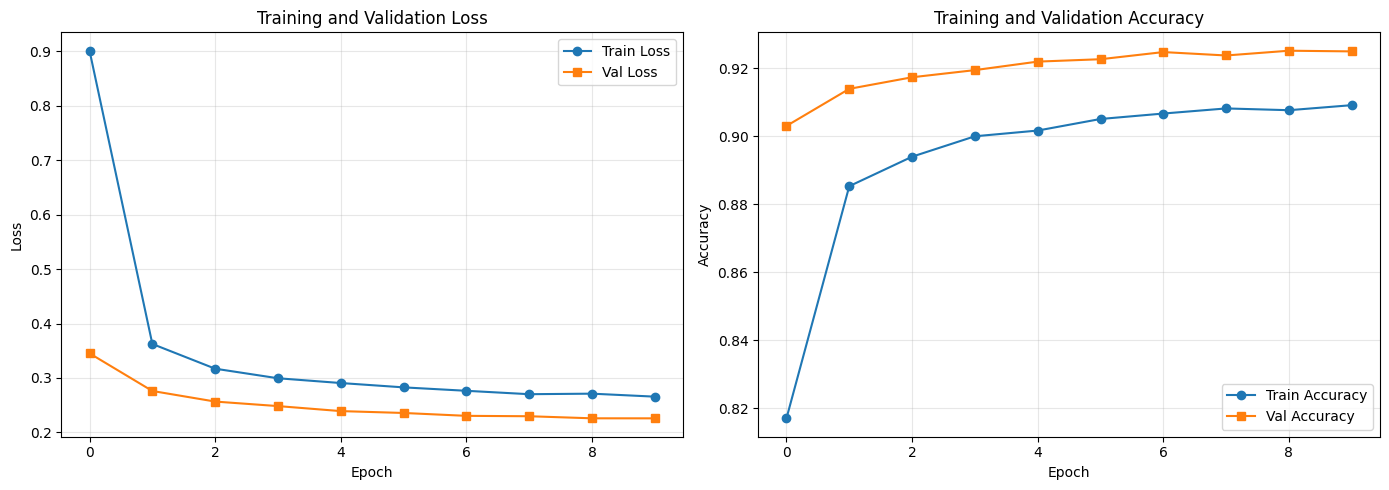

Training curves saved.


In [20]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'], label='Val Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history['train_acc'], label='Train Accuracy', marker='o')
axes[1].plot(history['val_acc'], label='Val Accuracy', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(config['save_dir'], 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Training curves saved.")

In [21]:
# Load best model and final evaluation
checkpoint = torch.load(os.path.join(config['checkpoint_dir'], 'best_model.pt'))
clf_model.load_state_dict(checkpoint['model_state_dict'])

print("Best model loaded.")
print(f"Best validation accuracy: {checkpoint['val_acc']:.4f}")

Best model loaded.
Best validation accuracy: 0.9251


In [23]:
# Final evaluation with detailed metrics
val_loss, val_acc, all_preds, all_labels = evaluate(clf_model, val_loader, criterion, device)

print(f"\n{'='*60}")
print("FINAL EVALUATION RESULTS")
print(f"{'='*60}")
print(f"\nValidation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")

# Per-class metrics
print(f"\n{'Class':<15} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("-" * 51)

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

for i, class_name in enumerate(cifar10_classes):
    # Create binary labels for this class
    y_true_binary = (all_labels == i).astype(int)
    y_pred_binary = (all_preds == i).astype(int)

    precision = precision_score(y_true_binary, y_pred_binary, zero_division=0)
    recall = recall_score(y_true_binary, y_pred_binary, zero_division=0)
    f1 = f1_score(y_true_binary, y_pred_binary, zero_division=0)
    print(f"{class_name:<15} {precision:<12.4f} {recall:<12.4f} {f1:<12.4f}")

print(f"\n{'='*60}")

Evaluating: 100%|██████████| 157/157 [00:13<00:00, 11.38it/s]



FINAL EVALUATION RESULTS

Validation Loss: 0.2260
Validation Accuracy: 0.9251

Class           Precision    Recall       F1-Score    
---------------------------------------------------
airplane        0.9375       0.9450       0.9412      
automobile      0.9708       0.9630       0.9669      
bird            0.9311       0.8920       0.9111      
cat             0.8452       0.8680       0.8564      
deer            0.8931       0.9190       0.9059      
dog             0.8836       0.8880       0.8858      
frog            0.9087       0.9260       0.9173      
horse           0.9685       0.9220       0.9447      
ship            0.9648       0.9600       0.9624      
truck           0.9537       0.9680       0.9608      



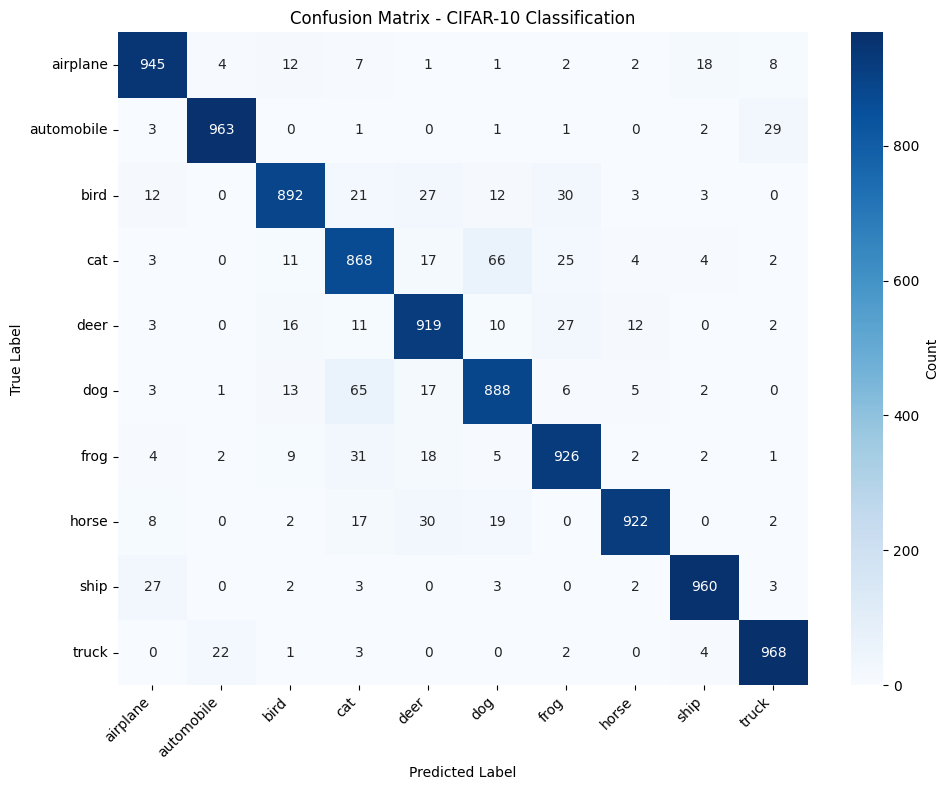

Confusion matrix saved.


In [24]:
# Confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=cifar10_classes,
            yticklabels=cifar10_classes,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - CIFAR-10 Classification')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(config['save_dir'], 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Confusion matrix saved.")

## 8. Save Results & Artifacts

In [26]:
import pandas as pd
# Save training history
history_df = pd.DataFrame(history)
history_df.to_csv(os.path.join(config['save_dir'], 'training_history.csv'), index=False)

# Save results summary
results_summary = {
    'model_name': config['model_name'],
    'best_val_accuracy': float(best_val_acc),
    'final_val_accuracy': float(val_acc),
    'final_val_loss': float(val_loss),
    'num_epochs_trained': len(history['train_loss']),
    'lora_rank': config['lora_r'],
    'lora_alpha': config['lora_alpha'],
    'trainable_parameters': trainable_params,
    'total_parameters': total_params,
    'trainable_ratio': trainable_params / total_params,
    'batch_size': config['batch_size'],
    'learning_rate': config['learning_rate'],
}

with open(os.path.join(config['save_dir'], 'results_summary.json'), 'w') as f:
    json.dump(results_summary, f, indent=2)

print("Results saved to Google Drive.")
print(json.dumps(results_summary, indent=2))

Results saved to Google Drive.
{
  "model_name": "ViT-B-32",
  "best_val_accuracy": 0.9251,
  "final_val_accuracy": 0.9251,
  "final_val_loss": 0.22600573230131416,
  "num_epochs_trained": 10,
  "lora_rank": 16,
  "lora_alpha": 32,
  "trainable_parameters": 64902657,
  "total_parameters": 152751873,
  "trainable_ratio": 0.42488943490728914,
  "batch_size": 64,
  "learning_rate": 0.0001
}


In [27]:
# Save LoRA weights only (much smaller)
lora_model_path = os.path.join(config['save_dir'], 'lora_adapter')
clf_model.vision_model.save_pretrained(lora_model_path)

print(f"LoRA weights saved to: {lora_model_path}")
print(f"\nFinal outputs saved to: {config['save_dir']}")
print("\nFiles created:")
for f in os.listdir(config['save_dir']):
    fpath = os.path.join(config['save_dir'], f)
    if os.path.isfile(fpath):
        size = os.path.getsize(fpath) / (1024**2)  # Size in MB
        print(f"  - {f} ({size:.2f} MB)")
    else:
        print(f"  - {f}/ (directory)")

LoRA weights saved to: /content/gdrive/MyDrive/openclip_lora_cifar10/lora_adapter

Final outputs saved to: /content/gdrive/MyDrive/openclip_lora_cifar10

Files created:
  - results_summary.json (0.00 MB)
  - lora_adapter/ (directory)
  - checkpoints/ (directory)
  - confusion_matrix.png (0.11 MB)
  - config.json (0.00 MB)
  - training_curves.png (0.09 MB)
  - training_history.csv (0.00 MB)


## 9. Inference Example

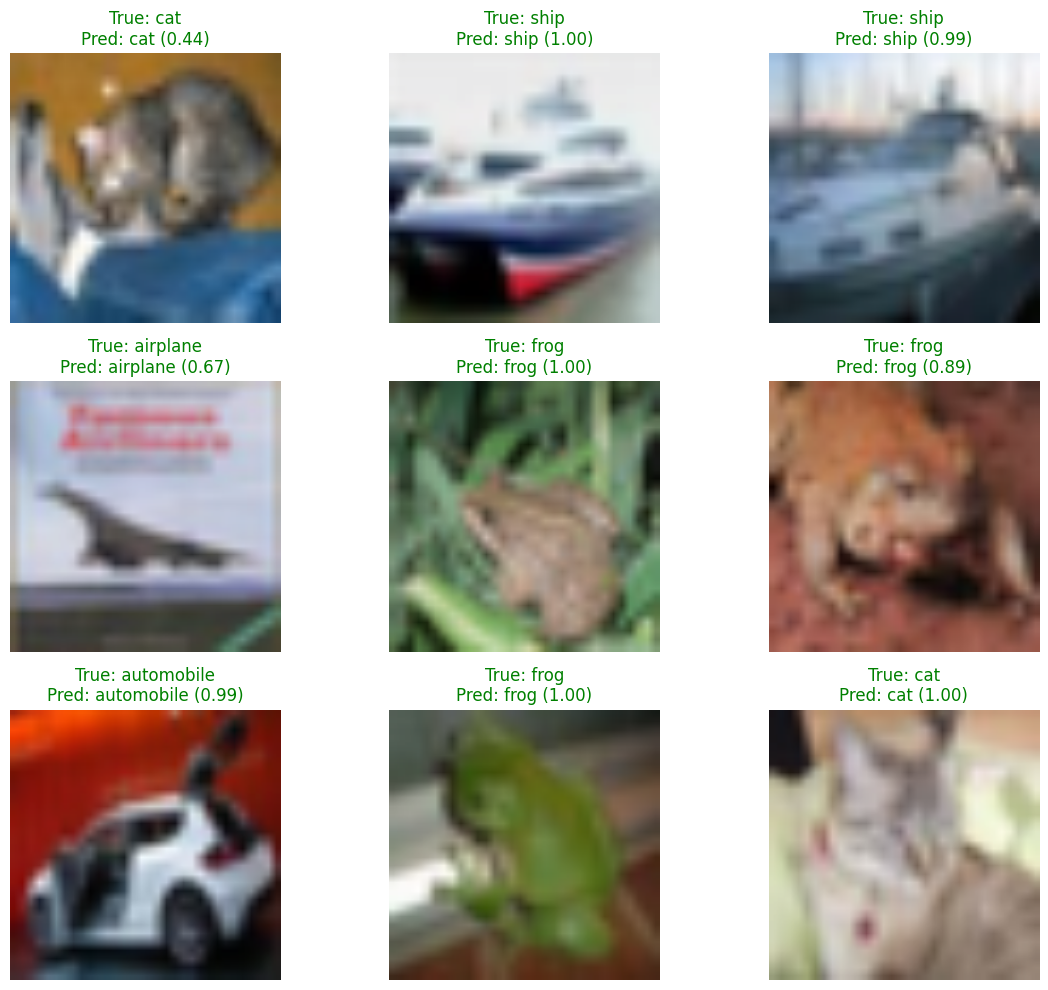

Inference example completed.


In [28]:
# Demonstrate inference on sample images
def predict_batch(model, images, device):
    """Make predictions on a batch of images"""
    model.eval()
    with torch.no_grad():
        images = images.to(device)
        logits = model(images)
        probs = torch.softmax(logits, dim=1)
        preds = logits.argmax(dim=1)
    return preds.cpu().numpy(), probs.cpu().numpy()

# Get a batch from validation set
sample_images, sample_labels = next(iter(val_loader))

# Predict
preds, probs = predict_batch(clf_model, sample_images, device)

# Visualize
n_samples = 9
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()

for idx in range(n_samples):
    # Denormalize image
    img = sample_images[idx].cpu().numpy().transpose(1, 2, 0)
    img = np.clip((img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])), 0, 1)

    # Get prediction
    true_class = cifar10_classes[sample_labels[idx]]
    pred_class = cifar10_classes[preds[idx]]
    confidence = probs[idx][preds[idx]]

    # Plot
    axes[idx].imshow(img)
    color = 'green' if preds[idx] == sample_labels[idx] else 'red'
    axes[idx].set_title(f"True: {true_class}\nPred: {pred_class} ({confidence:.2f})", color=color)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(config['save_dir'], 'inference_samples.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Inference example completed.")

## 10. Summary & Statistics

In [29]:
print(f"""
╔═══════════════════════════════════════════════════════════╗
║         OPENCLIP LORA FINE-TUNING SUMMARY              ║
╚═══════════════════════════════════════════════════════════╝

📊 MODEL CONFIGURATION:
  • Architecture:          {config['model_name']}
  • Pre-trained:          {config['pretrained']}
  • Total Parameters:      {total_params:,}
  • Trainable Parameters:  {trainable_params:,}
  • Trainable Ratio:       {trainable_params/total_params*100:.2f}%

🎛️  LORA CONFIGURATION:
  • Rank (r):              {config['lora_r']}
  • Alpha:                 {config['lora_alpha']}
  • Dropout:               {config['lora_dropout']}
  • Target Modules:        {', '.join(config['lora_target_modules'])}

📈 TRAINING STATISTICS:
  • Epochs:                {len(history['train_loss'])}
  • Batch Size:            {config['batch_size']}
  • Learning Rate:         {config['learning_rate']}
  • Optimizer:             AdamW
  • Scheduler:             Cosine Annealing

🎯 RESULTS:
  • Best Val Accuracy:     {best_val_acc:.4f}
  • Final Val Accuracy:    {val_acc:.4f}
  • Final Val Loss:        {val_loss:.4f}
  • Train Set Size:        {len(train_dataset):,}
  • Val Set Size:          {len(val_dataset):,}

💾 OUTPUTS SAVED TO:
  {config['save_dir']}

  Files:
  ✓ best_model.pt
  ✓ lora_adapter/ (LoRA weights)
  ✓ training_history.csv
  ✓ training_curves.png
  ✓ confusion_matrix.png
  ✓ inference_samples.png
  ✓ results_summary.json
  ✓ config.json

""")


╔═══════════════════════════════════════════════════════════╗
║         OPENCLIP LORA FINE-TUNING SUMMARY              ║
╚═══════════════════════════════════════════════════════════╝

📊 MODEL CONFIGURATION:
  • Architecture:          ViT-B-32
  • Pre-trained:          openai
  • Total Parameters:      152,751,873
  • Trainable Parameters:  64,902,657
  • Trainable Ratio:       42.49%

🎛️  LORA CONFIGURATION:
  • Rank (r):              16
  • Alpha:                 32
  • Dropout:               0.1
  • Target Modules:        q_proj, v_proj

📈 TRAINING STATISTICS:
  • Epochs:                10
  • Batch Size:            64
  • Learning Rate:         0.0001
  • Optimizer:             AdamW
  • Scheduler:             Cosine Annealing

🎯 RESULTS:
  • Best Val Accuracy:     0.9251
  • Final Val Accuracy:    0.9251
  • Final Val Loss:        0.2260
  • Train Set Size:        50,000
  • Val Set Size:          10,000

💾 OUTPUTS SAVED TO:
  /content/gdrive/MyDrive/openclip_lora_cifar10

  Files

## Notes

### Next Steps:
1. **Load saved model**: Use the checkpoint to load the fine-tuned model for inference
2. **Merge LoRA weights**: Apply LoRA adapter to the base model for deployment
3. **Fine-tune text encoder**: Uncomment lines to also apply LoRA to the text encoder
4. **Adjust hyperparameters**: Modify `config` dict to experiment with different settings
5. **Use different OpenCLIP models**: Try `ViT-B-16`, `ViT-L-14`, `ViT-g-14` for better performance

### Key Features:
- ✓ Parameter-efficient fine-tuning with LoRA (~2% trainable parameters)
- ✓ Early stopping with patience
- ✓ Learning rate scheduling (Cosine Annealing)
- ✓ Gradient accumulation support
- ✓ Comprehensive evaluation metrics
- ✓ All results saved to Google Drive
- ✓ Inference examples included

### Troubleshooting:
- **Out of memory**: Reduce `batch_size` or use `gradient_accumulation_steps`
- **Slow training**: Use `num_workers=0` if data loading is the bottleneck
- **Poor accuracy**: Try larger LoRA rank or different OpenCLIP model
- **Drive space**: LoRA adapters are ~100MB; full checkpoint is larger